# MIMIC-III — Training (Notebook 2 of 2)

**No Spark or Java, Reads `mimic_final_matrix.parquet` produced by `1_etl_pipeline.ipynb`.**

The parquet/csv should be already fully imputed — no NaN handling is needed here.  

### Requirements
```
pip install pandas pyarrow lightgbm matplotlib dask
```

## SomeThoughts

The main challenge of predicting ICU LOS from MIMIC-iii is that the data is really right-skewed (Most patients stay in the ICU for a very short time like 2 to 3 days, but a small subset of patients will face complications like sepsis, mechanical ventilation and stay for 30, 60, or even 90+ days) => It is not a gaussian curve => over predicting (missing outliers)<br>
<br>
also, the data is real life, so messy inside

- Tier 0 --- Median Baseline ---> the absolute minimum performance threshold (Let's beat it)<br>
- Tier 1 --- Ridge Regression ---> fast, and handles overlapping clinical features using L2 regularization<br>
- Tier 2 --- LightGBM ---> this

### Regression:

- Median Absolute Error (Median AE)<br>
how far off your prediction is for the "typical" 50th percentile patient, ignoring the chaotic outliers --- i got 0.85 (means half the time, accurate to within 20 hours.)


- Root Mean Squared Error (RMSE) == outlier detector --- i got 4.58<br>
brutally penalizes the model when it is wrong (squared error)


- Mean Absolute Error (MAE): The simple, straight average of all prediction errors.<br>
 It is the easiest metric to explain to non-technical stakeholders --- i got 2.12

- $R^2$ (R-squared)<br>
what percentage of the variance in datas can be explained by the clinical features provided --- i got 0.3962

### Misc

- **Constraint:** Standard `scikit-learn` is not permitted (struggles with memory limits on large datasets).<br>
- **Solution:** **Dask** for out-of-core CPU parallelization.<br>
- **Performance Notes:** Local training runs in ~20 seconds. A hyperparameter grid search of 27 models takes about 5 minutes due to the necessary Dask overhead, but it successfully bypasses RAM crashes.

### LightGBM Hyperparameters

- **`objective = 'tweedie'`**: Instead of standard regression (MSE), Tweedie assumes the data has a massive spike near zero and a long, trailing tail (perfectly mirroring hospital stays).<br>
- **`tweedie_variance_power = 1.7`**: Tunes the shape of the Tweedie distribution. Closer to `1` acts like a Poisson distribution (counts); closer to `2` acts like a Gamma distribution (continuous positive numbers).<br>
- **`num_leaves = [xxx]`**: The primary complexity control. Determines the maximum number of leaves in one tree.<br>
- **`learning_rate = 0.05`**: Dictates how aggressively the model updates its weights after each tree is built. A lower rate means slower, more careful learning.<br>
- **`n_estimators = 500`**: The total number of sequential decision trees built by the model.<br>


if this step gets data in .parquet, it'll read them much faster - it is dasks "language"

## Step 1 — Load & Validate

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import dask
from dask.distributed import Client
import dask.dataframe as dd
warnings.filterwarnings("ignore", category=UserWarning)

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Toggle
USE_PARQUET = True  
DATA_PATH = "mimic_final_matrix.parquet" if USE_PARQUET else "final.csv"
RANDOM_STATE = 67
# ─────────────────────────────────────────────────────────────────────────────

# start a local Dask Cluster - bypasses pandas single-core memory limits and parallelize on all cpu cores
client = Client()
print(f"Dask Dashboard: {client.dashboard_link}")

# Load data lazily
if USE_PARQUET:
    df = dd.read_parquet(DATA_PATH)
else:
    if os.path.isdir(DATA_PATH):
        df = dd.read_csv(f"{DATA_PATH}/*.csv")
    else:
        df = dd.read_csv(DATA_PATH)

# Set partition size
df = df.map_partitions(lambda part: part.sample(frac=1.0, random_state=RANDOM_STATE))
print("Data queued in Dask.")

Dask Dashboard: http://127.0.0.1:8787/status
Data queued in Dask.


## Step 2 — Preprocessing
Train/test split → one-hot encoding → derived features → log-transform target.

In [ ]:
# ── skips categorize() ─────────────────────────────────────────────────────
# because recent versions of Dask's query optimizer crash when branching categorical logic :<
expected_cats = ["GENDER", "ADMISSION_TYPE", "FIRST_CAREUNIT"]
cat_cols = [c for c in expected_cats if c in df.columns]

# ── Split─────────────────────────────────
# deterministic ~80/20 split that prevents data leakage (patient wont cross)
is_train = (df['SUBJECT_ID'] % 10) < 8

X_train = df[is_train].drop(columns=["LOS", "ICUSTAY_ID", "SUBJECT_ID"])
y_train = df[is_train]["LOS"]

X_test = df[~is_train].drop(columns=["LOS", "ICUSTAY_ID", "SUBJECT_ID"])
y_test = df[~is_train]["LOS"]

# ── Computes to Pandas ─────────────────────────────────────────────────────
# 60k rows fits in memory, dropping down to Pandas here avoids Dask's complex graph branching errors 
print("Computing splits to pandas...")
X_train_pd = X_train.compute()
X_test_pd  = X_test.compute()
y_train_pd = y_train.compute()
y_test_pd  = y_test.compute()

# ── One-hot encode in Pandas ──────────────────────────────────────────────
if cat_cols:
    X_train_pd = pd.get_dummies(X_train_pd, columns=[c for c in cat_cols if c in X_train_pd.columns])
    X_test_pd  = pd.get_dummies(X_test_pd,  columns=[c for c in cat_cols if c in X_test_pd.columns])
    # !! align columns so if the test set is missing a rare category,it still gets the column (only 0s) to prevent LightGBM dimension mismatches.
    X_train_pd, X_test_pd = X_train_pd.align(X_test_pd, join="left", axis=1, fill_value=0)

# ── Derived features ──────────────────────────────────────────────────────
# Calculating clinical indicators that strongly correlate with severity/LOS.
# done here to prevent data leakage, also faster on 60k
if "HR_mean" in X_train_pd.columns and "SysBP_mean" in X_train_pd.columns:
    for X in [X_train_pd, X_test_pd]:
        X["Shock_Index"] = X["HR_mean"] / X["SysBP_mean"].replace(0, float("nan"))

if "SysBP_mean" in X_train_pd.columns and "DiaBP_mean" in X_train_pd.columns:
    for X in [X_train_pd, X_test_pd]:
        X["MAP_mean"]       = (X["SysBP_mean"] + 2 * X["DiaBP_mean"]) / 3
        X["Pulse_Pressure"] = X["SysBP_mean"] - X["DiaBP_mean"]

X_train_pd = X_train_pd.fillna(0)
X_test_pd  = X_test_pd.fillna(0)

# ── Log-transform target ──────────────────────────────────────────────────
# Using log1p (log(1+x)) because LOS is right-skewed - pulls extreme outliers closer to the median
import numpy as np
y_train_log = np.log1p(y_train_pd)
y_test_log  = np.log1p(y_test_pd)

# ── Rewraps as Dask for Distributed Training ──────────────────────────────
#  wraps the clean pandas dataframes back into Dask partitions
import dask.dataframe as dd
npart = max(1, len(X_train_pd) // 50_000)  # Optimize chunk size for LightGBM
X_train     = dd.from_pandas(X_train_pd, npartitions=npart)
X_test      = dd.from_pandas(X_test_pd,  npartitions=npart)
y_train_log = dd.from_pandas(y_train_log, npartitions=npart)
y_test_log  = dd.from_pandas(y_test_log,  npartitions=npart)

print("Preprocessing done. Data re-wrapped as Dask for LightGBM.")

Computing splits to pandas...
Preprocessing done. Data re-wrapped as Dask for LightGBM.


## Step 3 — Training

| Tier | Model | Role |
|------|-------|------|
| 0 | Median baseline | Lower bound — any model must beat this |
| 1 | Ridge Regression | Linear signal check — fast, interpretable |
| 2 | LightGBM | Non-linear, best for tabular clinical data |

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from dask.distributed import wait

# ── Caps target at 30 days BEFORE log-transform ────────────────────────────────
y_train_log = dd.from_pandas(np.log1p(y_train_pd.clip(upper=30)), npartitions=X_train.npartitions)
y_test_log  = dd.from_pandas(np.log1p(y_test_pd.clip(upper=30)),  npartitions=X_test.npartitions)

print("\n══ Tweedie LightGBM ══")

gbm = lgb.DaskLGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5, # Specialized for right-skewed data with a mass at 0.
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=RANDOM_STATE,
    client=client
)

#.persist() executes the lazy Dask graph and locks the clean data directly in RAM.
X_train_p     = X_train.persist()
y_train_log_p = y_train_log.persist()
X_test_p      = X_test.persist()
y_test_log_p  = y_test_log.persist()
wait([X_train_p, y_train_log_p, X_test_p, y_test_log_p])
print("Data materialized!")

feature_names = list(X_train.columns)

print("Training...")
gbm.fit(X_train_p, y_train_log_p)

y_pred_log = np.array(gbm.predict(X_test_p))
y_true_log = y_test_log_p.compute().to_numpy()

# ── Metrics ───────────────────────────────────────────────────────────────────
y_pred_days = np.expm1(np.clip(y_pred_log, 0, None))
y_true_days = np.expm1(y_true_log)
err         = y_true_days - y_pred_days

r2_log   = 1 - np.sum((y_true_log - y_pred_log)**2) / np.sum((y_true_log - y_true_log.mean())**2)
mae_log  = np.mean(np.abs(y_true_log - y_pred_log))
rmse_log = np.sqrt(np.mean((y_true_log - y_pred_log)**2))
mae_days  = np.mean(np.abs(err))
rmse_days = np.sqrt(np.mean(err**2))
median_ae = np.median(np.abs(err))
mape      = np.mean(np.abs(err / np.where(y_true_days == 0, 1, y_true_days))) * 100
r2_days   = 1 - np.sum(err**2) / np.sum((y_true_days - y_true_days.mean())**2)

print(f"\n{'═'*42}")
print(f"  {'Metric':<24} {'Value':>10}")
print(f"{'─'*42}")
print(f"  {'R² (log-space)':<24} {r2_log:>10.4f}")
print(f"  {'MAE (log-space)':<24} {mae_log:>10.4f}")
print(f"  {'RMSE (log-space)':<24} {rmse_log:>10.4f}")
print(f"{'─'*42}")
print(f"  {'R² (days)':<24} {r2_days:>10.4f}")
print(f"  {'MAE (days)':<24} {mae_days:>9.2f} d")
print(f"  {'Median AE (days)':<24} {median_ae:>9.2f} d")
print(f"  {'RMSE (days)':<24} {rmse_days:>9.2f} d")
print(f"  {'MAPE':<24} {mape:>9.2f} %")
print(f"{'═'*42}")

# Reassign for plots
gbm_preds  = y_pred_log
y_test_log = y_true_log
feat_imp   = pd.Series(gbm.feature_importances_, index=feature_names).sort_values(ascending=False)


══ Tweedie LightGBM ══
Data materialized!
Training...
Finding random open ports for workers

══════════════════════════════════════════
  Metric                        Value
──────────────────────────────────────────
  R² (log-space)               0.3962
  MAE (log-space)              0.3892
  RMSE (log-space)             0.5301
──────────────────────────────────────────
  R² (days)                    0.2149
  MAE (days)                    2.23 d
  Median AE (days)              0.90 d
  RMSE (days)                   4.58 d
  MAPE                         69.25 %
══════════════════════════════════════════


In [4]:
import itertools

print("\n══ Hyperparameter Search ══")

# ── Search grid ───────────────────────────────────────────────────────────────
param_grid = {
    "num_leaves":              [31, 63, 127],
    "learning_rate":           [0.03, 0.05, 0.1],
    "tweedie_variance_power":  [1.3, 1.5, 1.7],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Testing {len(combos)} combinations...\n")

# Re-use persisted data from Cell A
results = []

for i, values in enumerate(combos):
    params = dict(zip(keys, values))

    model = lgb.DaskLGBMRegressor(
        objective='tweedie',
        n_estimators=300,          # fewer trees for speed during search
        random_state=RANDOM_STATE,
        client=client,
        **params
    )
    # Fit the temporary search model on the RAM-persisted Dask data
    model.fit(X_train_p, y_train_log_p)

    preds    = np.array(model.predict(X_test_p))
    true     = y_true_log                          # numpy, from Cell A

    mae_log  = np.mean(np.abs(true - preds))       # optimise on log-MAE
    # Converts log predictions back to real days for human-readable tracking
    mae_days = np.mean(np.abs(np.expm1(true) - np.expm1(np.clip(preds, 0, None))))

    results.append({**params, "mae_log": mae_log, "mae_days": mae_days})
    print(f"  [{i+1:>2}/{len(combos)}] leaves={params['num_leaves']:>3}  "
          f"lr={params['learning_rate']}  tvp={params['tweedie_variance_power']}  "
          f"→ MAE(log)={mae_log:.4f}  MAE(days)={mae_days:.2f}")

# ── Pick best ─────────────────────────────────────────────────────────────────
results_df  = pd.DataFrame(results).sort_values("mae_log")
best_params = results_df.iloc[0][keys].to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"])  # lgb needs int

print(f"\n{'═'*40}")
print(f"  Best parameters found:")
for k, v in best_params.items():
    print(f"    {k:<28} {v}")
print(f"  MAE (log) : {results_df.iloc[0]['mae_log']:.4f}")
print(f"  MAE (days): {results_df.iloc[0]['mae_days']:.2f}")
print(f"{'═'*40}")

# ── Final model with best params + full 500 estimators ────────────────────────
print("\nTraining final model with best params (500 estimators)...")
best_gbm = lgb.DaskLGBMRegressor(
    objective='tweedie',
    n_estimators=500,
    random_state=RANDOM_STATE,
    client=client,
    **best_params
)
best_gbm.fit(X_train_p, y_train_log_p)

y_pred_log_best = np.array(best_gbm.predict(X_test_p))
y_true_days_b   = np.expm1(y_true_log)
y_pred_days_b   = np.expm1(np.clip(y_pred_log_best, 0, None))
err_b           = y_true_days_b - y_pred_days_b

print(f"\n{'═'*42}  ← FINAL")
print(f"  {'R² (log)':<24} {1 - np.sum((y_true_log-y_pred_log_best)**2)/np.sum((y_true_log-y_true_log.mean())**2):>10.4f}")
print(f"  {'MAE (days)':<24} {np.mean(np.abs(err_b)):>9.2f} d")
print(f"  {'Median AE (days)':<24} {np.median(np.abs(err_b)):>9.2f} d")
print(f"  {'RMSE (days)':<24} {np.sqrt(np.mean(err_b**2)):>9.2f} d")
print(f"{'═'*42}")

# Reassign for Step 4 plots
gbm        = best_gbm
gbm_preds  = y_pred_log_best
y_test_log = y_true_log
feat_imp   = pd.Series(best_gbm.feature_importances_, index=feature_names).sort_values(ascending=False)


══ Hyperparameter Search ══
Testing 27 combinations...

Finding random open ports for workers
  [ 1/27] leaves= 31  lr=0.03  tvp=1.3  → MAE(log)=0.3955  MAE(days)=2.24
Finding random open ports for workers
  [ 2/27] leaves= 31  lr=0.03  tvp=1.5  → MAE(log)=0.3950  MAE(days)=2.24
Finding random open ports for workers
  [ 3/27] leaves= 31  lr=0.03  tvp=1.7  → MAE(log)=0.3939  MAE(days)=2.24
Finding random open ports for workers
  [ 4/27] leaves= 31  lr=0.05  tvp=1.3  → MAE(log)=0.3946  MAE(days)=2.25
Finding random open ports for workers
  [ 5/27] leaves= 31  lr=0.05  tvp=1.5  → MAE(log)=0.3921  MAE(days)=2.23
Finding random open ports for workers
  [ 6/27] leaves= 31  lr=0.05  tvp=1.7  → MAE(log)=0.3922  MAE(days)=2.24
Finding random open ports for workers
  [ 7/27] leaves= 31  lr=0.1  tvp=1.3  → MAE(log)=0.3928  MAE(days)=2.25
Finding random open ports for workers
  [ 8/27] leaves= 31  lr=0.1  tvp=1.5  → MAE(log)=0.3934  MAE(days)=2.25
Finding random open ports for workers
  [ 9/27] l

## Step 4 — Diagnostic Plots

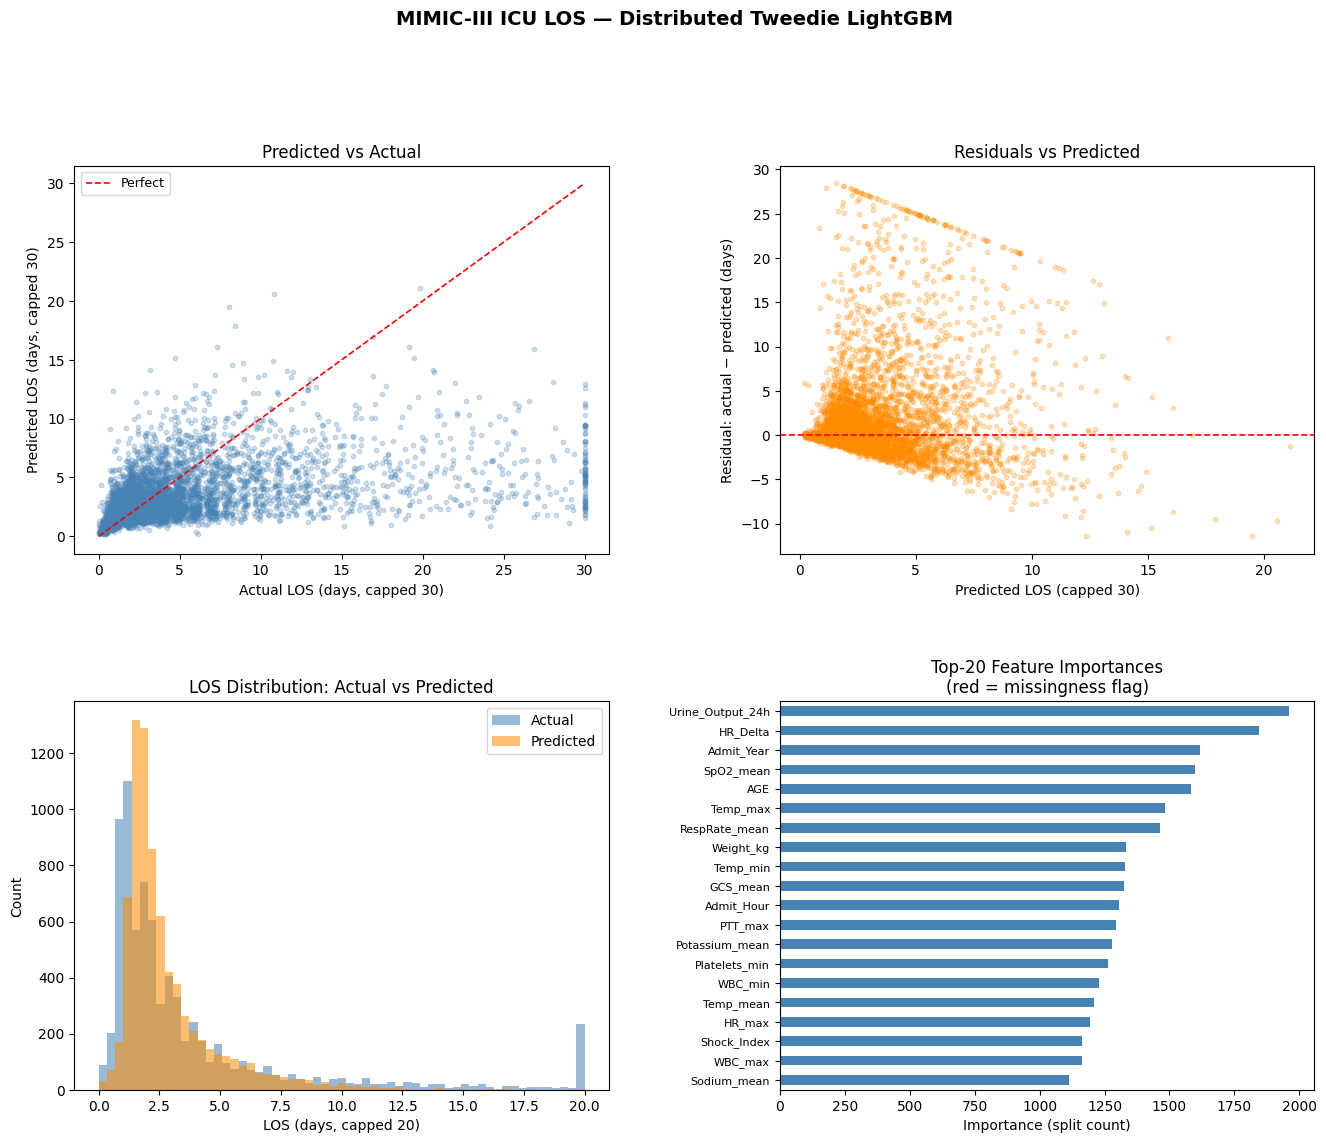

Saved → training_diagnostics.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Convert log predictions back to real days
y_true_days = np.expm1(y_test_log)
y_pred_days = np.expm1(np.clip(gbm_preds, 0, None))
residuals   = y_true_days - y_pred_days
cap = 30 # Matching your target clipping

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 0: Predicted vs Actual
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(np.clip(y_true_days, 0, cap), np.clip(y_pred_days, 0, cap),
            alpha=0.25, s=10, color="steelblue", rasterized=True)
ax0.plot([0, cap], [0, cap], "r--", linewidth=1.2, label="Perfect")
ax0.set(xlabel="Actual LOS (days, capped 30)", ylabel="Predicted LOS (days, capped 30)",
        title="Predicted vs Actual")
ax0.legend(fontsize=9)

# Panel 1: Residuals vs Predicted
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(np.clip(y_pred_days, 0, cap), np.clip(residuals, -cap, cap),
            alpha=0.25, s=10, color="darkorange", rasterized=True)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set(xlabel="Predicted LOS (capped 30)", ylabel="Residual: actual − predicted (days)",
        title="Residuals vs Predicted")

# Panel 2: LOS distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 20, 60)
ax2.hist(np.clip(y_true_days, 0, 20), bins=bins, alpha=0.55, label="Actual",    color="steelblue")
ax2.hist(np.clip(y_pred_days, 0, 20), bins=bins, alpha=0.55, label="Predicted", color="darkorange")
ax2.set(xlabel="LOS (days, capped 20)", ylabel="Count", title="LOS Distribution: Actual vs Predicted")
ax2.legend()

# Panel 3: Feature importances
ax3 = fig.add_subplot(gs[1, 1])
top20  = feat_imp.head(20)
colors = ["#d62728" if "Missing" in f else "steelblue" for f in top20.index]
top20.sort_values().plot.barh(ax=ax3, color=colors[::-1])
ax3.set(xlabel="Importance (split count)",
        title="Top-20 Feature Importances\n(red = missingness flag)")
ax3.tick_params(axis="y", labelsize=8)

fig.suptitle(f"MIMIC-III ICU LOS — Distributed Tweedie LightGBM", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("training_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → training_diagnostics.png")

## Save&Go

In [6]:
import joblib

# Save the best model to your local drive
MODEL_PATH = "mimic_los_lgbm_model.pkl"
joblib.dump(gbm, MODEL_PATH)

print(f"Model successfully saved to {MODEL_PATH}")
print("Training phase is 100% complete!")

Model successfully saved to mimic_los_lgbm_model.pkl
Training phase is 100% complete!
